In [111]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from conformalHDC.models import *
from conformalHDC.methods import *
from conformalHDC.utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def run_experiment(small_var, large_var, score_type_list, random_state):
    alpha = 0.05
    
    # Initialize sampler
    sampler = NormalClusters(2, 2)
    
    # Define means and covariances
    mean1 = [2, 2]
    cov1 = [[small_var, 0], [0, small_var]]  # Small variance

    mean2 = [6, 6]
    cov2 = [[large_var, 0], [0, large_var]]  # High variance

    # Sample data
    X, Y = sampler.sample(means=[mean1, mean2], covs=[cov1, cov2], sizes=[500, 5000])

    # Split the data into training and test sets
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=random_state)

    # Initialize the conformal predictor with the training data
    conformal = ConformalHDC(X_train, Y_train, random_state=random_state)

    # Make predictions on the test set
    pred = conformal.predict(X_test)
    pred = np.array(pred).reshape(-1, 1)

    # Initialize result df
    df_m = []  # for marginal results
    df_lc = [] # for label-conditional results
    
    # Evaluate the predictions (hdc method)
    df_m_tmp = eval_m_psets(pred, Y_test)
    df_m_tmp['method'] = 'HDC'
    df_m.append(df_m_tmp)
    
    df_lc_tmp = eval_lc_psets(pred, Y_test)
    df_lc_tmp['method'] = 'HDC'
    df_lc.append(df_lc_tmp)

    # Generate conformal prediction sets
    for score_name, score_type in score_type_list.items():
        pset = conformal.conformalPS(X_test, alpha, score_type=score_type, allow_empty=True)

        # Evaluate the conformal prediction sets (conformal method)
        df_m_tmp = eval_m_psets(pset, Y_test)
        df_m_tmp['method'] = score_name
        df_m.append(df_m_tmp)
        
        df_lc_tmp = eval_lc_psets(pset, Y_test)
        df_lc_tmp['method'] = score_name
        df_lc.append(df_lc_tmp)

    # Concatenate results for this run
    result_m = pd.concat(df_m, ignore_index=True)
    result_m['small_var'] = small_var
    result_m['large_var'] = large_var
    result_m['random_state'] = random_state
    
    result_lc = pd.concat(df_lc, ignore_index=True)
    result_lc['small_var'] = small_var
    result_lc['large_var'] = large_var
    result_lc['random_state'] = random_state
    
    return result_m, result_lc

In [113]:
# Initialize empty lists to store results
all_results_m = []
all_results_lc = []

small_var_list = np.arange(0.1, 2.2, 0.5)
large_var_list = np.arange(5.0, 5.1, 0.2) 
score_type_list = {"Vanilla-distance":None, 
                   "Discount":"normalized_discount", 
                   #"discount":"discount", 
                   "Ratio":"normalized_ratio",
                   #"ratio":"ratio",
                   "Penalized": "penalized"}                     
rep = 300

for small_var in small_var_list:
    for large_var in large_var_list:
        for i in tqdm(range(rep)):
            random_state = i  # Set the random state for each run

            # Run the experiment
            result_m, result_lc = run_experiment(small_var, large_var, score_type_list, random_state)
            
            # Append the results to the list
            all_results_m.append(result_m)
            all_results_lc.append(result_lc)

# Concatenate all the results from all repetitions and variance settings
final_m_df = pd.concat(all_results_m, ignore_index=True)
final_lc_df = pd.concat(all_results_lc, ignore_index=True)

100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [00:42<00:00,  7.11it/s]


In [114]:
final_m_df

,M-coverage,M-size,M-size|cov,method,small_var,large_var,random_state
0,0.901818,1.000000,1.000000,HDC,0.1,5.0,0
1,0.960000,1.025455,1.068182,Vanilla-distance,0.1,5.0,0
2,0.952727,0.954545,1.000000,Discount,0.1,5.0,0
3,0.958182,0.960000,1.000000,Ratio,0.1,5.0,0
4,0.961818,0.963636,1.000000,Penalized,0.1,5.0,0
...,...,...,...,...,...,...,...
7495,0.907273,1.000000,1.000000,HDC,2.1,5.0,299
7496,0.963636,1.100000,1.139623,Vanilla-distance,2.1,5.0,299
7497,0.967273,1.027273,1.035714,Discount,2.1,5.0,299
7498,0.961818,1.029091,1.030246,Ratio,2.1,5.0,299


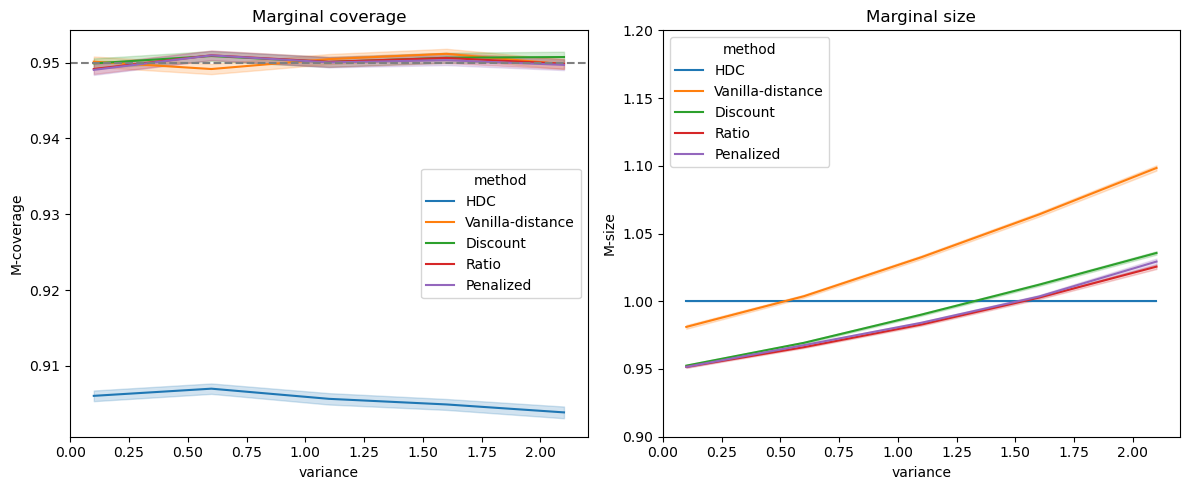

In [115]:
import seaborn as sns
# Set up the figure size
plt.figure(figsize=(12, 5))

# Plot 1: M-coverage vs var (aggregated over random_state)
plt.subplot(1, 2, 1)
sns.lineplot(x='small_var', y='M-coverage', hue='method', data=final_m_df, errorbar='se')
plt.axhline(0.95, color='gray', linestyle='--', label='nominal level')  # Add horizontal line at 0.95
plt.title('Marginal coverage')
plt.xlabel('variance')
plt.ylabel('M-coverage')

# Plot 2: M-size vs var (aggregated over random_state)
plt.subplot(1, 2, 2)
plt.ylim(0.9, 1.2)  # Set y-axis limit for M-size plot
sns.lineplot(x='small_var', y='M-size', hue='method', data=final_m_df, errorbar='se')
plt.title('Marginal size')
plt.xlabel('variance')
plt.ylabel('M-size')

# Adjust layout for clear display
plt.tight_layout()

plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\marginal_comp.png', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

In [116]:
final_lc_df

,class0-LC-coverage,class0-LC-size,class0-LC-size|cov,class1-LC-coverage,class1-LC-size,class1-LC-size|cov,method,small_var,large_var,random_state
0,1.000000,1.000000,1.000000,0.892430,1.000000,1.000000,HDC,0.1,5.0,0
1,0.958333,1.687500,1.760870,0.960159,0.962151,1.002075,Vanilla-distance,0.1,5.0,0
2,0.958333,0.958333,1.000000,0.952191,0.954183,1.000000,Discount,0.1,5.0,0
3,0.937500,0.937500,1.000000,0.960159,0.962151,1.000000,Ratio,0.1,5.0,0
4,0.979167,0.979167,1.000000,0.960159,0.962151,1.000000,Penalized,0.1,5.0,0
...,...,...,...,...,...,...,...,...,...,...
7495,0.962963,1.000000,1.000000,0.901210,1.000000,1.000000,HDC,2.1,5.0,299
7496,0.981481,1.425926,1.433962,0.961694,1.064516,1.106918,Vanilla-distance,2.1,5.0,299
7497,0.944444,1.074074,1.078431,0.969758,1.022177,1.031185,Discount,2.1,5.0,299
7498,0.962963,1.055556,1.057692,0.961694,1.026210,1.027254,Ratio,2.1,5.0,299


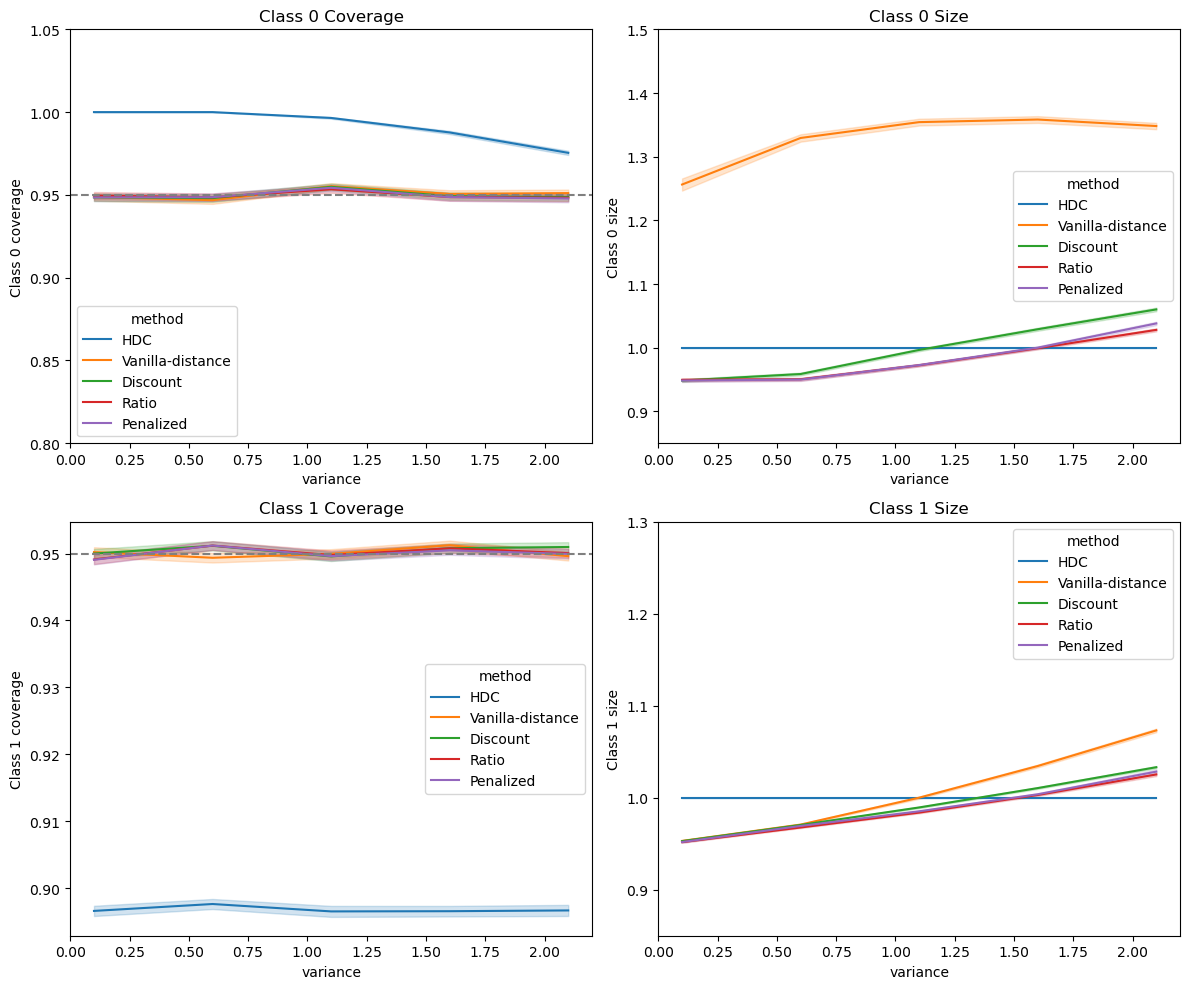

In [117]:
# Set up the figure size
plt.figure(figsize=(12, 10))

# Plot for Class 0
plt.subplot(2, 2, 1)
sns.lineplot(x='small_var', y='class0-LC-coverage', hue='method', data=final_lc_df, errorbar='se')
plt.ylim(0.8, 1.05)  # Adjust the y-axis limit as needed
plt.axhline(0.95, color='gray', linestyle='--', label='0.95 Threshold')
plt.title('Class 0 Coverage')
plt.xlabel('variance')
plt.ylabel('Class 0 coverage')

plt.subplot(2, 2, 2)
sns.lineplot(x='small_var', y='class0-LC-size', hue='method', data=final_lc_df, errorbar='se')
plt.ylim(0.85, 1.5)  # Adjust the y-axis limit as needed
plt.title('Class 0 Size')
plt.xlabel('variance')
plt.ylabel('Class 0 size')

# Plot for Class 1
plt.subplot(2, 2, 3)
sns.lineplot(x='small_var', y='class1-LC-coverage', hue='method', data=final_lc_df, errorbar='se')
plt.axhline(0.95, color='gray', linestyle='--', label='0.95 Threshold')
plt.title('Class 1 Coverage')
plt.xlabel('variance')
plt.ylabel('Class 1 coverage')

plt.subplot(2, 2, 4)
sns.lineplot(x='small_var', y='class1-LC-size', hue='method', data=final_lc_df, errorbar='se')
plt.ylim(0.85, 1.3)  # Adjust the y-axis limit as needed
plt.title('Class 1 Size')
plt.xlabel('variance')
plt.ylabel('Class 1 size')

# Adjust layout for clear display
plt.tight_layout()

# Save the plot to a file before displaying
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\lc_comp.png', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

In [75]:
alpha = 0.05
large_var = 5.0
small_var = 1.6
# Initialize sampler
sampler = NormalClusters(2, 2)

# Define means and covariances
mean1 = [2, 2]
cov1 = [[small_var, 0], [0, small_var]]  # Small variance

mean2 = [6, 6]
cov2 = [[large_var, 0], [0, large_var]]  # High variance

# Sample data
X, Y = sampler.sample(means=[mean1, mean2], covs=[cov1, cov2], sizes=[2000, 5000])

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=random_state)

# Initialize the conformal predictor with the training data
conformal = ConformalHDC(X_train, Y_train, random_state=random_state)

In [78]:
x_min, x_max =np.min(X_train[:, 0])-1, np.max(X_train[:, 0])+1
y_min, y_max =np.min(X_train[:, 1])-1, np.max(X_train[:, 1])+1


inputs_test=X_test
labels_test=Y_test
alpha_test_point=0.2
alpha_region=0.1

test_point=np.array([2.3,4])

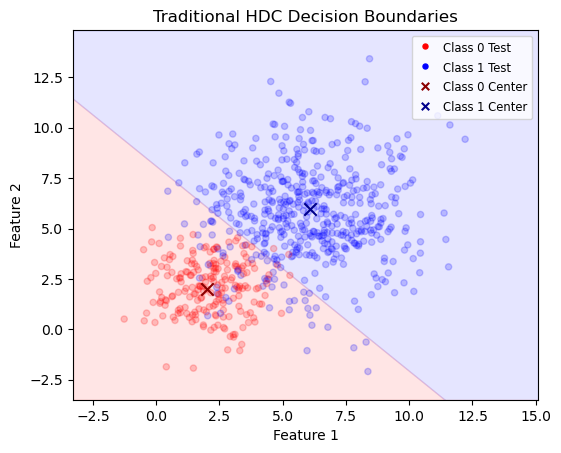

In [96]:
midpoint = (conformal.classHVs[0] + conformal.classHVs[1]) / 2
slope = (conformal.classHVs[1][1] - conformal.classHVs[0][1]) / (conformal.classHVs[1][0] - conformal.classHVs[0][0])
perp_slope = -1 / slope

# Equation of the perpendicular bisector: y = perp_slope * (x - midpoint_x) + midpoint_y
x_vals = np.linspace(x_min, x_max, 100)
y_vals = perp_slope * (x_vals - midpoint[0]) + midpoint[1]

# Create the plot
plt.figure(figsize=(6,4.8))

# HDC Boundary
plt.fill_between(x_vals, y_vals, y_min, color='red', alpha=alpha_region)
plt.fill_between(x_vals, y_vals, y_max, color='blue', alpha=alpha_region)

plt.scatter([], [], color='red', label='Class 0 Test')  # Empty scatter to add red color to the legend
plt.scatter([], [], color='blue', label='Class 1 Test')  # Empty scatter to add blue color to the legend

# Scatter plot of the test points
colors = ['red' if c == 0 else 'blue' for c in labels_test]
plt.scatter(inputs_test[:, 0], inputs_test[:, 1], c=colors,  s=20, alpha=alpha_test_point)

#plt.scatter(test_point[0], test_point[1], c='green',  s=30, alpha=0.8, label='Test point')

# Scatter plot of the class centers
plt.scatter(conformal.classHVs[0][0], conformal.classHVs[0][1], color='darkred', marker='x', s=80, label='Class 0 Center')
plt.scatter(conformal.classHVs[1][0], conformal.classHVs[1][1], color='darkblue', marker='x', s=80, label='Class 1 Center')

# Add labels and other settings
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Traditional HDC Decision Boundaries')
plt.legend(fontsize='small', markerscale=0.6, handlelength=1.5, handleheight=1.5, loc='upper right')


#plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\clusters_train.png')
#plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\clusters_train_center.png')
#plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\clusters_test.png')
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\hdc_test_boundary.png')

plt.show()

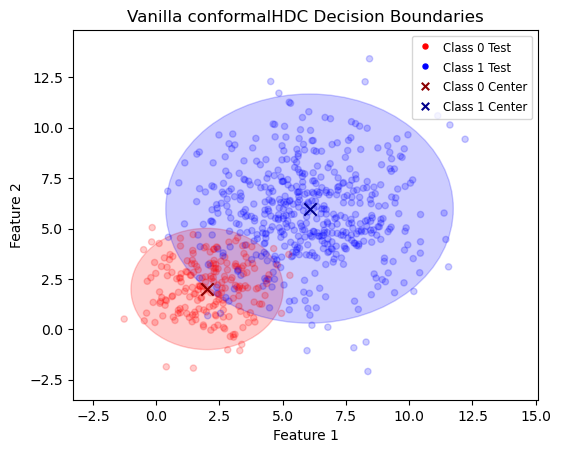

In [97]:
# Conformal boundary for vanilla distance 
_ = conformal.conformalPS(X_test, alpha, score_type=None, allow_empty=True)

# Create the plot
fig, ax = plt.subplots(figsize=(6,4.8))

# Plot decision boundaries as circles
circle1 = plt.Circle(conformal.classHVs[0], conformal.quantiles[0], color='r', alpha=0.2, fill=True)
circle2 = plt.Circle(conformal.classHVs[1], conformal.quantiles[1], color='b', alpha=0.2, fill=True)

ax.add_artist(circle1)
ax.add_artist(circle2)

# Scatter plot of the test points
ax.scatter([], [], color='red', label='Class 0 Test')  # Empty scatter to add red color to the legend
ax.scatter([], [], color='blue', label='Class 1 Test')  # Empty scatter to add blue color to the legend

# Scatter plot of the test points
colors = ['red' if c == 0 else 'blue' for c in labels_test]
ax.scatter(inputs_test[:, 0], inputs_test[:, 1], c=colors,  s=20, alpha=alpha_test_point)

# Scatter plot of the class centers
ax.scatter(conformal.classHVs[0][0], conformal.classHVs[0][1], color='darkred', marker='x', s=80, label='Class 0 Center')
ax.scatter(conformal.classHVs[1][0], conformal.classHVs[1][1], color='darkblue', marker='x', s=80, label='Class 1 Center')

# Labels and legend
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Vanilla conformalHDC Decision Boundaries')
ax.legend(fontsize='small', markerscale=0.6, handlelength=1.5, handleheight=1.5, loc='upper right')
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\conformal_test_boundary.png')

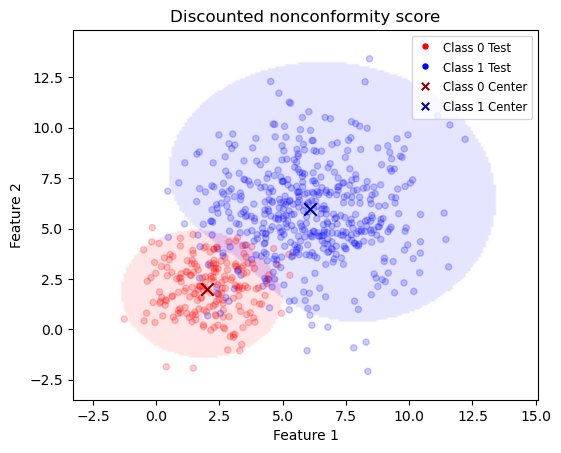

In [107]:
# Conformal boundary for normalized discounted nonconformity score
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
psets = conformal.conformalPS(grid_points, alpha, score_type="normalized_discount", allow_empty=True)

# Create a color map for the decision regions
region_colors = np.zeros((xx.shape[0], xx.shape[1], 3))  # RGB color map
        
# Assign colors based on prediction sets
for i, pset in enumerate(psets):
    row, col = divmod(i, xx.shape[1])
    if len(pset) == 0:
        region_colors[row, col] = [1, 1, 1]  # White for empty regions
    elif len(pset) == 1:
        if 0 in pset:
            region_colors[row, col] = [1, 0.8, 0.8]  # Light red for Class 0
        if 1 in pset:
            region_colors[row, col] = [0.8, 0.8, 1]  # Light blue for Class 1
    else:
        region_colors[row, col] = [0.8, 0.5, 0.8]  # Purple for overlap (mix of red and blue)

# Plot the decision boundaries
fig, ax = plt.subplots(figsize=(6,4.8))
ax.imshow(region_colors, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.5, aspect='auto')

# Scatter plot of the test points
ax.scatter([], [], color='red', label='Class 0 Test')  # Empty scatter to add red color to the legend
ax.scatter([], [], color='blue', label='Class 1 Test')  # Empty scatter to add blue color to the legend

# Scatter plot of the test points
colors = ['red' if c == 0 else 'blue' for c in labels_test]
ax.scatter(inputs_test[:, 0], inputs_test[:, 1], c=colors,  s=20, alpha=alpha_test_point)

# Scatter plot of the class centers
ax.scatter(conformal.classHVs[0][0], conformal.classHVs[0][1], color='darkred', marker='x', s=80, label='Class 0 Center')
ax.scatter(conformal.classHVs[1][0], conformal.classHVs[1][1], color='darkblue', marker='x', s=80, label='Class 1 Center')

# Labels and legend
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Discounted nonconformity score')
ax.legend(fontsize='small', markerscale=0.6, handlelength=1.5, handleheight=1.5, loc='upper right')
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\discounted_test_boundary.png')

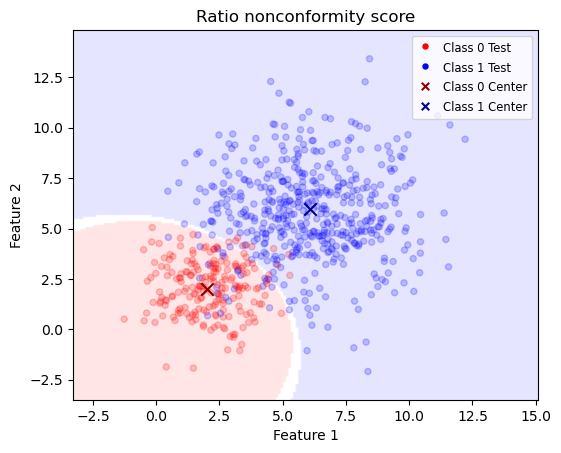

In [108]:
# Conformal boundary for normalized discounted nonconformity score
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
psets = conformal.conformalPS(grid_points, alpha, score_type="normalized_ratio", allow_empty=True)

# Create a color map for the decision regions
region_colors = np.zeros((xx.shape[0], xx.shape[1], 3))  # RGB color map
        
# Assign colors based on prediction sets
for i, pset in enumerate(psets):
    row, col = divmod(i, xx.shape[1])
    if len(pset) == 0:
        region_colors[row, col] = [1, 1, 1]  # White for empty regions
    elif len(pset) == 1:
        if 0 in pset:
            region_colors[row, col] = [1, 0.8, 0.8]  # Light red for Class 0
        if 1 in pset:
            region_colors[row, col] = [0.8, 0.8, 1]  # Light blue for Class 1
    else:
        region_colors[row, col] = [0.8, 0.5, 0.8]  # Purple for overlap (mix of red and blue)

# Plot the decision boundaries
fig, ax = plt.subplots(figsize=(6,4.8))
ax.imshow(region_colors, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.5, aspect='auto')

# Scatter plot of the test points
ax.scatter([], [], color='red', label='Class 0 Test')  # Empty scatter to add red color to the legend
ax.scatter([], [], color='blue', label='Class 1 Test')  # Empty scatter to add blue color to the legend

# Scatter plot of the test points
colors = ['red' if c == 0 else 'blue' for c in labels_test]
ax.scatter(inputs_test[:, 0], inputs_test[:, 1], c=colors,  s=20, alpha=alpha_test_point)

# Scatter plot of the class centers
ax.scatter(conformal.classHVs[0][0], conformal.classHVs[0][1], color='darkred', marker='x', s=80, label='Class 0 Center')
ax.scatter(conformal.classHVs[1][0], conformal.classHVs[1][1], color='darkblue', marker='x', s=80, label='Class 1 Center')

# Labels and legend
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Ratio nonconformity score')
ax.legend(fontsize='small', markerscale=0.6, handlelength=1.5, handleheight=1.5, loc='upper right')
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\ratio_test_boundary.png')

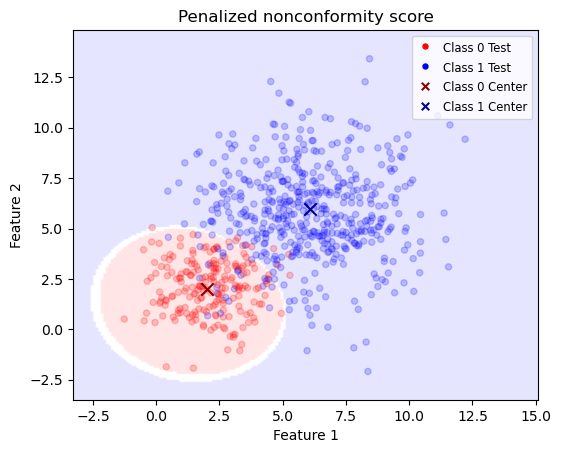

In [110]:
# Conformal boundary for normalized discounted nonconformity score
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
psets = conformal.conformalPS(grid_points, alpha, score_type="penalized", allow_empty=True)

# Create a color map for the decision regions
region_colors = np.zeros((xx.shape[0], xx.shape[1], 3))  # RGB color map
        
# Assign colors based on prediction sets
for i, pset in enumerate(psets):
    row, col = divmod(i, xx.shape[1])
    if len(pset) == 0:
        region_colors[row, col] = [1, 1, 1]  # White for empty regions
    elif len(pset) == 1:
        if 0 in pset:
            region_colors[row, col] = [1, 0.8, 0.8]  # Light red for Class 0
        if 1 in pset:
            region_colors[row, col] = [0.8, 0.8, 1]  # Light blue for Class 1
    else:
        region_colors[row, col] = [0.8, 0.5, 0.8]  # Purple for overlap (mix of red and blue)

# Plot the decision boundaries
fig, ax = plt.subplots(figsize=(6,4.8))
ax.imshow(region_colors, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.5, aspect='auto')

# Scatter plot of the test points
ax.scatter([], [], color='red', label='Class 0 Test')  # Empty scatter to add red color to the legend
ax.scatter([], [], color='blue', label='Class 1 Test')  # Empty scatter to add blue color to the legend

# Scatter plot of the test points
colors = ['red' if c == 0 else 'blue' for c in labels_test]
ax.scatter(inputs_test[:, 0], inputs_test[:, 1], c=colors,  s=20, alpha=alpha_test_point)

# Scatter plot of the class centers
ax.scatter(conformal.classHVs[0][0], conformal.classHVs[0][1], color='darkred', marker='x', s=80, label='Class 0 Center')
ax.scatter(conformal.classHVs[1][0], conformal.classHVs[1][1], color='darkblue', marker='x', s=80, label='Class 1 Center')

# Labels and legend
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Penalized nonconformity score')
ax.legend(fontsize='small', markerscale=0.6, handlelength=1.5, handleheight=1.5, loc='upper right')
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\penalized_test_boundary.png')